In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [8]:
df = pd.read_csv("noisy_curvefit_data.csv")
print(df.shape) # 100 rows, 6 columns
print(df.head())
print(df.tail())
# column names are x, y_noise_1, y_noise_2, y_noise_3, y_noise_4, y_noise_5

(100, 6)
          x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0 -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1 -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2 -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3 -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4 -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113
           x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850


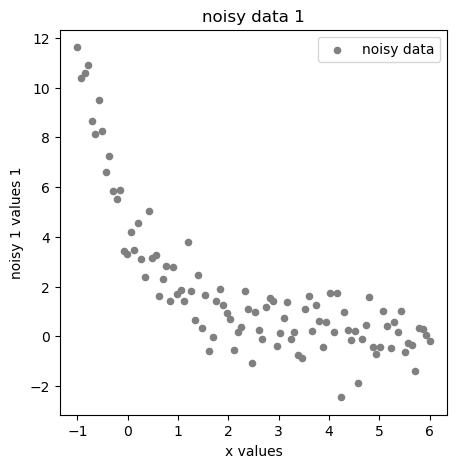

In [27]:
plt.figure(figsize=(5,5))

x = df["x"]
y_noise_1 = df["y_noise_1"]

plt.scatter(x, y_noise_1, c="grey", s=20, label="noisy data")
plt.xlabel("x values")
plt.ylabel("noisy 1 values 1")
plt.title("noisy data 1")
plt.legend()

plt.show()

In [18]:
# finding best fit

def model(x, A, k):
    return A * np.exp(-k * x)

p0 =  [1,1]
popt, pcov = curve_fit(model, x, y_noise_1, p0=p0)
A_fit, k_fit = popt

print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")

Fit: y = 4.71 * e^(-0.92 * x)


In [20]:
# calculating reduced chi squared
residuals = y_noise_1 - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof

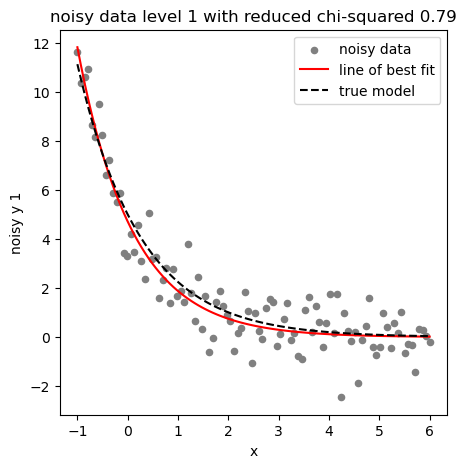

In [29]:
# plotting result
plt.figure(figsize=(5,5))

plt.scatter(x, y_noise_1, c="grey", s=20, label="noisy data")
plt.plot(x, 4.71 * np.e**(-0.92 * x), c="red", label="line of best fit")
plt.plot(x, model(x, 5, 0.8), linestyle="--", c="black", label="true model")

plt.xlabel("x")
plt.ylabel("noisy y 1")
plt.title(f"noisy data level 1 with reduced chi-squared {chi2_reduced:.2f}")
plt.legend()

plt.show()

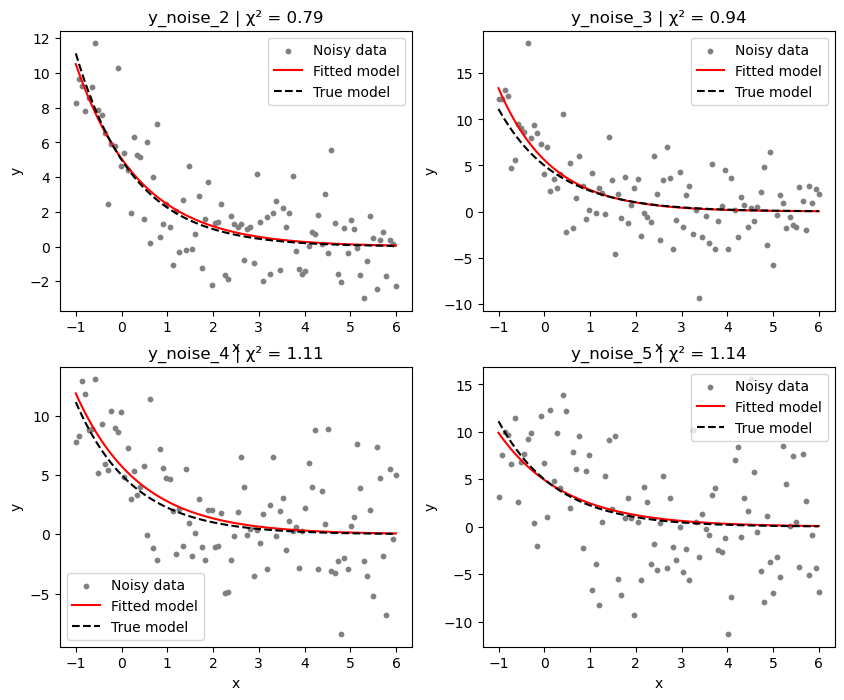

In [30]:
def fit_model(x,y):
    popt, pcov = curve_fit(model, x, y, p0=[1,1])
    residuals = y_noise_1 - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof
    return popt, chi2_reduced
fig, axes = plt.subplots(2, 2, figsize=(10,8))
noise_cols = ["y_noise_2", "y_noise_3", "y_noise_4", "y_noise_5"]

for ax, col in zip(axes.flatten(), noise_cols):
    y = df[col]
    popt, chi2_reduced = fit_model(x, y)
    A_fit, k_fit = popt
    ax.scatter(x, y, color="gray", s=10, label="Noisy data")
    ax.plot(x, model(x, A_fit, k_fit), color="red", label="Fitted model")
    ax.plot(x, model(x, 5, 0.8), "k--", label="True model")
    ax.set_title(f"{col} | χ² = {chi2_reduced:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()

plt.show()

In [31]:
# the lines get further apart and don't fit as well
# the reduced chi squared increases

In [32]:
results = []
for i in range (1,6):
    y=df[f"y_noise_{i}"]
    popt, chi2_reduced = fit_model(x,y)
    A_fit, k_fit = popt
    results.append([i, A_fit, k_fit, chi2_reduced])

results_df = pd.DataFrame(results, columns=["Noise Level", "A_fit", "k_fit", "Reduced Chi2"])
results_df.to_csv("noisy_parameters.csv", index=False)

In [33]:
# part 3: Kepler's 3rd Law